In [1]:
%matplotlib widget
import ipywidgets as widget
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd


# 1. import the Experiment object from LAMP 
from LAMP import Experiment

ROOT_FOLDER = str(Path.cwd().parent.parent) #Path.cwd().parent.parent#Path(__file__).resolve().parents[1] # absolute path to the experiment config files and other subfolders; 2 directories up in this case (assuming script in in ./scripts/eSpec/script.py)
sys.path.append(ROOT_FOLDER)
# import diagnostics.ESpec_
experiment = Experiment(ROOT_FOLDER)


Initializing LAMP, version 0.1.0


INFO: Logging level set to INFO


Using (User) DAQ: Fireball_DAQ
Adding (User) Diagnostic: HRM5 [ESpec_]
Adding (User) Diagnostic: HRM6 [ESpec_]
Adding (User) Diagnostic: Template [Template]
Adding (User) Diagnostic: SCOPE1 [BDot]
Adding (User) Diagnostic: SCOPE2 [BDot]
Adding (User) Diagnostic: ORCA [Orca]


In [3]:
# 3. get ESpec diagnostic object
orca_diagnostic = experiment.get_diagnostic('ORCA')

In [6]:
orca_config = experiment.diags['ORCA'].config
experiment_config = experiment.config
print("Experiment config")
print(experiment_config)
experiment_data_path = experiment_config['paths']['data_folder']
print("Experiment data path:", Path(experiment_data_path))
orca_data_path = diag_data_path = os.path.join(Path(experiment_data_path),
                                      Path(orca_config['data_folder'].lstrip("/\\")))
print("Orca data path:", orca_data_path)

Experiment config
{'setup': {'DAQ': 'Fireball_DAQ'}, 'paths': {'calibs_folder': './calibs/', 'user_diagnostics': 'diagnostics.', 'user_DAQs': 'DAQs.', 'data_folder': '/eos/project/h/hiradmat/HRMT Experiments/2025/HRMT68 - FIREBALL 3/FB3 repository/HRMT68_data/', 'root': PosixPath('/eos/home-i03/m/mmudra/SWAN_projects/Fireball_III_analysis'), 'local_config': PosixPath('/eos/home-i03/m/mmudra/SWAN_projects/Fireball_III_analysis/local.toml'), 'global_config': PosixPath('/eos/home-i03/m/mmudra/SWAN_projects/Fireball_III_analysis/global.toml')}, 'logging': {'level': 'INFO'}}
Experiment data path: /eos/project/h/hiradmat/HRMT Experiments/2025/HRMT68 - FIREBALL 3/FB3 repository/HRMT68_data
Orca data path: /eos/project/h/hiradmat/HRMT Experiments/2025/HRMT68 - FIREBALL 3/FB3 repository/HRMT68_data/orca_streak/original_files


In [40]:
filename = "test204354365.816802.dac"


In [41]:
absolut_path = os.path.join(Path(orca_data_path),
                                      Path(filename))
print("Path to file: ", absolut_path)

with open(absolut_path, "rb") as f:
    data = f.read()

len(data)
print(data[:500].decode("utf-8", errors="ignore"))

Path to file:  /eos/project/h/hiradmat/HRMT Experiments/2025/HRMT68 - FIREBALL 3/FB3 repository/HRMT68_data/orca_streak/original_files/test204354365.816802.dac
ns|	0	1	2	3	4	5	6	7	8	9	10	11	12	13	14	15	16	17	18	19	20	21	22	23	24	25	26	27	28	29	30	31	32	33	34	35	36	37	38	39	40	41	42	43	44	45	46	47	48	49	50	51	52	53	54	55	56	57	58	59	60	61	62	63	64	65	66	67	68	69	70	71	72	73	74	75	76	77	78	79	80	81	82	83	84	85	86	87	88	89	90	91	92	93	94	95	96	97	98	99	100	101	102	103	104	105	106	107	108	109	110	111	112	113	114	115	116	117	118	119	120	121	122	123	124	125	126	127	128	129	130	131	132	133	134	135	136	137	138	139	140	141	142	143	144	145	146	147	148	149	150	15


In [52]:
df = pd.read_csv(absolut_path, sep="\t", index_col=0).astype("uint8")

# Fix column/row label types
df.columns = pd.to_numeric(df.columns)
df.index = pd.to_numeric(df.index)

print("Min value: ", df.max().max())
print("Max value: ", df.min().min())
df

Min value:  244
Max value:  2


,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
ns|,,,,,,,,,,,,,,,,,,,,,
0.000000,101,104,103,105,106,101,102,98,101,104,...,104,97,96,105,98,100,101,90,101,100
0.003017,100,101,107,103,100,104,108,102,99,98,...,102,103,105,98,94,100,103,102,104,94
0.006032,101,102,96,103,100,102,104,100,101,100,...,102,99,99,96,98,93,100,98,96,99
0.009045,101,100,96,103,102,102,106,100,101,105,...,99,103,103,107,97,100,100,105,104,104
0.012055,101,104,101,108,90,103,100,106,103,103,...,100,101,98,96,94,110,101,99,103,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.495491,98,104,101,100,102,94,101,96,105,105,...,103,101,98,101,97,102,92,102,101,100
4.498064,107,100,103,100,99,98,94,102,98,102,...,111,100,111,98,103,102,103,102,110,99
4.500639,109,100,103,111,95,99,100,104,110,100,...,106,100,101,100,100,101,97,101,101,101


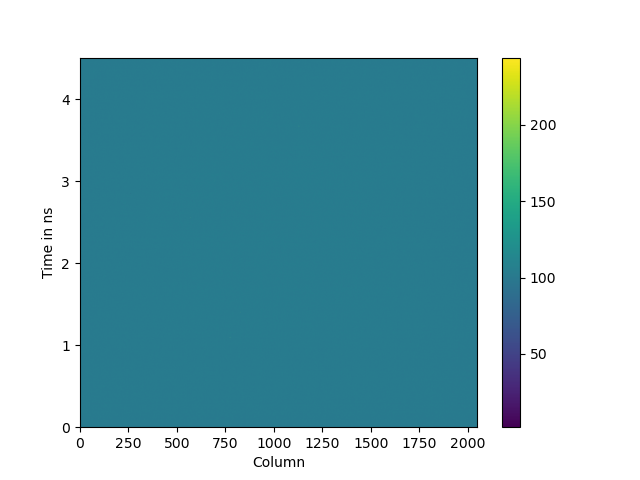

In [57]:
fig, ax = plt.subplots()

im = ax.imshow(
    df.values,
    aspect='auto',
    origin='lower',   # important: makes axes intuitive
    cmap='viridis',
    extent=[
        df.columns.min(), df.columns.max(),
        df.index.min(), df.index.max()
    ]
)

fig.colorbar(im, ax=ax)

ax.set_xlabel("Column")
ax.set_ylabel("Time in ns")

plt.show()